# LiDAR PCD Data Exploration
This notebook reads a Point Cloud Data (PCD) file generated by MATLAB (with float64 precision), explores its structure, and performs some basic analysis.

In [1]:
import os
import sys
import numpy as np
import open3d as o3d
import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Open3D:", o3d.__version__)
print("Numpy:", np.__version__)

Python: 3.11.14 | packaged by conda-forge | (main, Oct 13 2025, 14:29:50) [Clang 19.1.7 ]
Open3D: 0.19.0
Numpy: 2.4.6


## Loading the PCD File
The reason the original code was returning `0.0` for all points is due to the data format. The PCD file generated by MATLAB's `pcwrite` uses `SIZE 8` (double precision `float64`) for coordinates. 

The standard Open3D `o3d.io.read_point_cloud` function expects `SIZE 4` (`float32`) for binary data. When it tries to read the 64-bit values as 32-bit floats, it parses the upper/lower bytes incorrectly, resulting in arrays filled with zeros.

To correctly read double-precision binary PCD files, we use Open3D's Tensor API (`o3d.t.io.read_point_cloud`), which correctly respects the `SIZE 8` specification in the binary PCD header. Then, we can convert it back to the legacy PointCloud format for standard processing.

In [2]:
PCD_FILE = "lidar_data/frame_000011_t_001.000.pcd"

if not os.path.exists(PCD_FILE):
    print(f"Error: File {PCD_FILE} not found.")
else:
    # Use the Tensor API to correctly read float64 (SIZE 8) binary PCD files
    t_pcd = o3d.t.io.read_point_cloud(PCD_FILE)
    
    # Convert to legacy PointCloud format for standard Open3D operations
    pcd = t_pcd.to_legacy()
    
    print("Loaded point cloud:")
    print(pcd)
    
    # Extract points as a NumPy array
    points = np.asarray(pcd.points)
    print(f"Shape: {points.shape}")
    print(f"Total Points: {len(points)}")

Loaded point cloud:
PointCloud with 225000 points.
Shape: (225000, 3)
Total Points: 225000


## Cleaning the Point Cloud
MATLAB's exported organized point clouds frequently contain `NaN` or `Inf` values to represent invalid LiDAR returns (e.g. no hit in the sky). If we don't filter them out, algorithms like bounding boxes and downsampling will fail or act unpredictably (which is why downsampling yielded only 8 points before!).

In [3]:
# Remove NaN / Infinite points
print(f"Points before filtering: {len(pcd.points)}")
pcd.remove_non_finite_points()
print(f"Points after filtering: {len(pcd.points)}")

# Update points numpy array
points = np.asarray(pcd.points)

Points before filtering: 225000
Points after filtering: 42733


## Inspect Data
Let's verify that the valid points are now correctly loaded.

In [9]:
# Display first 10 points
print("First 10 points:")
for i, point in enumerate(points[:10]):
    print(f"Point {i:3d}: X={point[0]:9.4f}, Y={point[1]:9.4f}, Z={point[2]:9.4f}")

First 10 points:
Point   0: X=  -2.8853, Y=  -0.0000, Z=   0.0039
Point   1: X=  -2.8973, Y=  -0.0123, Z=  -0.0005
Point   2: X=  -2.9087, Y=  -0.0246, Z=  -0.0047
Point   3: X=  -2.9105, Y=  -0.0370, Z=  -0.0054
Point   4: X=  -2.8992, Y=  -0.0492, Z=  -0.0013
Point   5: X=  -2.9130, Y=  -0.0616, Z=  -0.0064
Point   6: X=  -2.9073, Y=  -0.0739, Z=  -0.0043
Point   7: X=  -2.8874, Y=  -0.0858, Z=   0.0028
Point   8: X=  -2.8766, Y=  -0.0978, Z=   0.0066
Point   9: X=  -2.9056, Y=  -0.1108, Z=  -0.0040


## Basic Analysis
We can calculate the bounding box, center of mass, and look at the distribution of the valid points.

In [5]:
# Calculate minimum and maximum bounds
min_bound = pcd.get_min_bound()
max_bound = pcd.get_max_bound()

print(f"Min Bounds (X, Y, Z): {min_bound}")
print(f"Max Bounds (X, Y, Z): {max_bound}")
print(f"Dimensions (W, L, H): {max_bound - min_bound}")

# Center of mass (mean of all points)
center = points.mean(axis=0)
print(f"Center of Mass: {center}")

Min Bounds (X, Y, Z): [-2.87633530e+01 -2.16286404e+01 -2.53846033e-02]
Max Bounds (X, Y, Z): [39.54674075 18.1666215   3.51018678]
Dimensions (W, L, H): [68.31009372 39.79526189  3.53557139]
Center of Mass: [ 4.37312617 -2.0309509   0.4196925 ]


## 2D Projections
Let's visualize the point cloud using 2D projections (Bird's Eye View and Side View). Because plotting 60,000+ points can be slow in matplotlib, we'll downsample the point cloud using a voxel grid first.

Points after downsampling: 1411


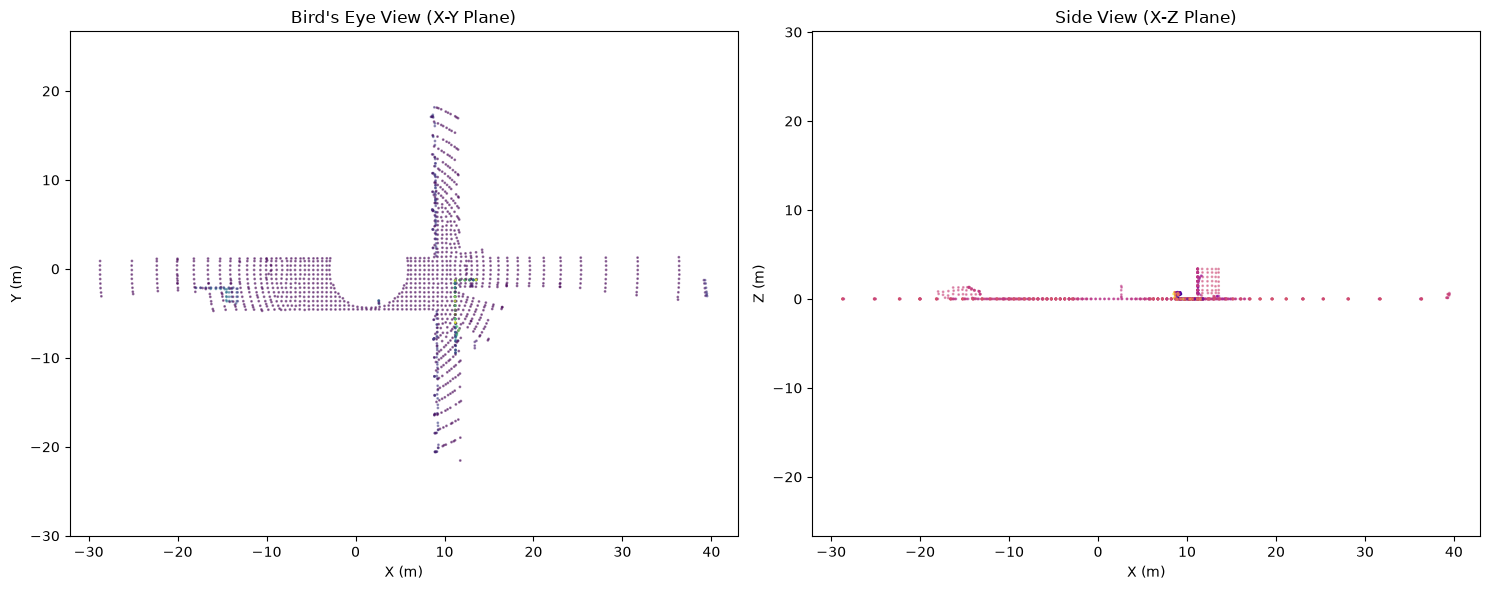

In [6]:
# Downsample using voxel grid for visualization
voxel_size = 0.5
downsampled_pcd = pcd.voxel_down_sample(voxel_size=voxel_size)
downsampled_points = np.asarray(downsampled_pcd.points)

print(f"Points after downsampling: {len(downsampled_points)}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bird's eye view (X-Y)
ax1.scatter(downsampled_points[:, 0], downsampled_points[:, 1], s=1, alpha=0.5, c=downsampled_points[:, 2], cmap='viridis')
ax1.set_title("Bird's Eye View (X-Y Plane)")
ax1.set_xlabel("X (m)")
ax1.set_ylabel("Y (m)")
ax1.axis('equal')

# Side view (X-Z)
ax2.scatter(downsampled_points[:, 0], downsampled_points[:, 2], s=1, alpha=0.5, c=downsampled_points[:, 1], cmap='plasma')
ax2.set_title("Side View (X-Z Plane)")
ax2.set_xlabel("X (m)")
ax2.set_ylabel("Z (m)")
ax2.axis('equal')

plt.tight_layout()
plt.show()

## Interactive 3D Visualization
Uncomment the code below to open an interactive Open3D window. Note: this will open an external window.

In [7]:
# o3d.visualization.draw_geometries([downsampled_pcd], 
#                                     window_name="LiDAR Point Cloud",
#                                     width=800, height=600)